In [2]:
import utils

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tifffile
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from scipy.stats import norm, skewnorm

import os
import re



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.8.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import utils
import os

input_directory = r"E:\Users\Sebastian_van_Dijk\TEMP"
organoids = ["TL01", "TL09","TL10","TL11","TL12","TL31"]
dirs = []
for organoid in organoids:
    dir_path = os.path.join(input_directory, organoid, "properties")
    dirs.append(dir_path)

all_df = pd.DataFrame()
for organoid, directory in zip(organoids, dirs):
    for file in os.listdir(directory):
        if file.endswith(".txt"):
            df = pd.read_csv(os.path.join(directory, file), sep="\t")
            if organoid == "TL01":
                df["type"] = "WT"
            elif organoid == "TL26":
                df["type"] = "CRC"
            else:
                df["type"] = "mixed"
            df["organoid"] = organoid
            all_df = pd.concat([all_df, df], ignore_index=True)

all_df["ratioWT_CRC"] = all_df["raw_WT"] / all_df["raw_CRC"]



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.7.1+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'E:\\Users\\Sebastian_van_Dijk\\TEMP\\TL01\\properties'

In [15]:
df

,label,z,y,x,bounding_box,volume,area_WT,raw_WT,area_CRC,raw_CRC,Phenotype,type,organoid
0,1,1.592878,31.710720,145.026432,"(0, 17, 121, 5, 50, 172)",2724.0,2724.0,107.593245,2724.0,139.082232,CRC,mixed,TL31
1,2,0.502924,66.688304,178.958480,"(0, 51, 162, 2, 84, 198)",1710.0,1710.0,107.840351,1710.0,147.695322,CRC,mixed,TL31
2,3,0.428212,75.352645,115.767003,"(0, 60, 105, 2, 90, 127)",794.0,794.0,108.108312,794.0,129.226700,CRC,mixed,TL31
3,4,0.500000,87.396175,198.342896,"(0, 74, 188, 2, 102, 209)",732.0,732.0,108.256831,732.0,148.155738,CRC,mixed,TL31
4,5,0.365912,100.827175,150.847437,"(0, 85, 141, 2, 117, 162)",839.0,839.0,108.052443,839.0,129.520858,CRC,mixed,TL31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,306,22.197531,202.190329,213.412551,"(21, 189, 203, 24, 216, 223)",972.0,972.0,107.884774,972.0,114.017490,CRC,mixed,TL31
306,307,21.000000,211.465909,138.431818,"(21, 204, 132, 22, 221, 146)",176.0,176.0,108.034091,176.0,117.556818,CRC,mixed,TL31
307,308,21.515982,220.223744,237.465753,"(21, 214, 232, 23, 227, 244)",219.0,219.0,107.214612,219.0,121.447489,CRC,mixed,TL31
308,309,22.165574,229.445902,208.193443,"(21, 221, 198, 24, 238, 218)",610.0,610.0,107.824590,610.0,117.613115,CRC,mixed,TL31


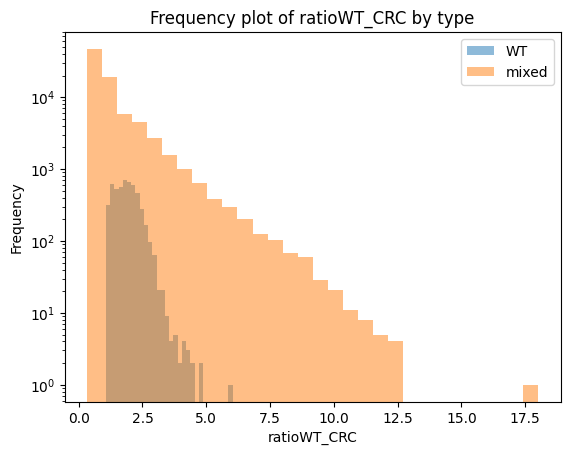

In [13]:
for t in all_df["type"].unique():
    subset = all_df[all_df["type"] == t]
    plt.hist(subset["ratioWT_CRC"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

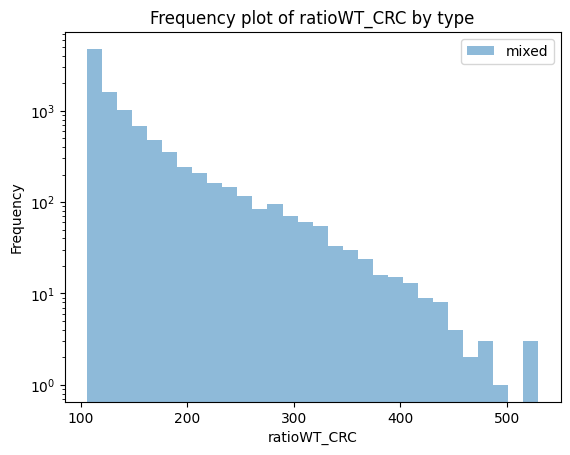

In [18]:
subset = all_df[all_df["organoid"] == "TL11"]
plt.hist(subset["raw_WT"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

In [6]:
import tifffile
from scipy import ndimage
import os

input_directory = r"C:\Users\6331823\Desktop\Train model whole organoid segmentation"
for organoid in os.listdir(input_directory):
    if organoid.endswith(".tif"):
        original = os.path.join(input_directory, organoid)
        original = tifffile.imread(original)
        resize_factors = (200 / original.shape[0] , 200 / original.shape[1])
        XY = ndimage.zoom(original, resize_factors, order=0)
        XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
        tifffile.imwrite(
            os.path.join(input_directory, "smoothed_XY", organoid),
            XY,
        )

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

# Your ratio data
ratios = np.array([
    0.843218545, 0.844873502, 1.668776133, 0.862274271, 0.809498911,
    0.737159537, 0.845353398, 0.775946006, 0.674322713, 0.649706156,
    1.112518394, 0.81620095, 1.705073941, 0.753885069, 0.77938578,
    0.793327383, 1.982575108, 0.737841096, 0.704847086, 0.701849541,
    0.847186436, 0.688447415, 0.695395085, 0.757498956, 1.13937129,
    2.126445938, 0.866231304, 2.3231805, 0.77348789, 0.761823995,
    0.773913337, 0.693962019, 0.760776805, 1.720121879, 0.753178687,
    1.351161179, 1.430329714, 0.846986397, 0.735142857, 1.350898729,
    1.972850816, 1.428831122, 1.641974047, 1.413566286, 0.810866686,
    0.837289092, 1.257008415, 0.869855683, 0.873884474, 0.865940501,
    0.908263305, 1.440489263, 1.289546879, 0.784626411, 0.888552437,
    0.822779145, 0.84824339
]).reshape(-1, 1)  # reshape for sklearn

for frame in range(14):
    ratios = pd.read_csv(f"E:\\Users\\Sebastian_van_Dijk\\Data_Anna\\s65\\properties\\Frame-{frame}_props.csv")
    ratios = ratios["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {frame}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    #cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")


frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124362
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8

In [11]:

input_directory = r"C:\Users\6331823\Local SSD\s65"

segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1

for file in range(15):
    segmented_stack = tifffile.imread(os.path.join(segmented, f"Frame-{file}_masks.tif"))
    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    df_wt = utils.properties_channel(segmented_stack, frame_WT, "WT")

    frame_CRC = frame[CRC_channel, :, :, :]
    df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final['wt_crc_ratio'] = df_final.apply(
        lambda row: row['raw_WT'] / row['raw_CRC'] if row['raw_CRC'] != 0 else 5,
        axis=1
    )

    ratios = df_final["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {file}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    # cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")

frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124364
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8

In [8]:
def get_properties(input_directory):
    segmented = os.path.join(input_directory, "segmented")
    cropped = os.path.join(input_directory, "cropped")
    WT_channel = 0
    CRC_channel = 1
    frame_data = []

    for file in range(len(os.listdir(segmented))):
        segmented_stack = tifffile.imread(
            os.path.join(segmented, f"Frame-{file}_masks.tif")
        )

        frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

        # Get properties of the masked nuclei, such as volume and location of every cell
        props = utils.properties_mask(segmented_stack)

        # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
        frame_WT = frame[WT_channel, :, :, :]

        median_value = np.median(frame_WT[frame_WT > 0])
        offset_WT = frame_WT.astype(np.float32) - median_value
        offset_WT[offset_WT < 0] = 0  # Clip negative values
        offset_WT = np.clip(offset_WT, 0, 255).astype(np.uint16)
        print(segmented_stack.shape, offset_WT.shape)
        df_wt = utils.properties_channel(segmented_stack, offset_WT, "WT")
        #df_wt = utils.properties_channel(segmented_stack, frame_WT, "WT")

        frame_CRC = frame[CRC_channel, :, :, :]
        median_value = np.median(frame_CRC[frame_CRC > 0])
        offset_CRC = frame_CRC.astype(np.float32) - median_value
        offset_CRC[offset_CRC < 0] = 0  # Clip negative values
        offset_CRC = np.clip(offset_CRC, 0, 255).astype(np.uint16)
        df_crc = utils.properties_channel(segmented_stack, offset_CRC, "CRC")
        #df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

        # Combine the information of nuclei, WT, and CRC channel into a single dataframe
        df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
        df_final["file"] = file
        df_final["wt_crc_ratio"] = df_final.apply(
            lambda row: (row["raw_WT"]+1e-6) / (row["raw_CRC"]+1e-6), axis=1
        )
        frame_data.append(df_final)

    properties = pd.concat(frame_data, ignore_index=True)
    return properties

# test = r"C:\Users\6331823\Local SSD\Data_Anna\crc\EXpansion_CRC_1"
# test_properties = get_properties(test)
# properties["wt_crc_ratio"].to_numpy().reshape(-1, 1)

(30, 154, 154) (30, 154, 154)
(24, 172, 176) (24, 172, 176)
(24, 199, 196) (24, 199, 196)
(29, 220, 219) (29, 220, 219)
(30, 251, 242) (30, 251, 242)
(32, 270, 270) (32, 270, 270)
(36, 309, 308) (36, 309, 308)
(38, 341, 340) (38, 341, 340)
(44, 388, 384) (44, 388, 384)
(51, 422, 426) (51, 422, 426)
(31, 457, 462) (31, 457, 462)
(50, 470, 470) (50, 470, 470)
(34, 415, 420) (34, 415, 420)
(38, 369, 361) (38, 369, 361)
(16, 99, 90) (16, 99, 90)
(17, 111, 104) (17, 111, 104)
(20, 117, 116) (20, 117, 116)
(19, 134, 135) (19, 134, 135)
(22, 155, 154) (22, 155, 154)
(22, 172, 170) (22, 172, 170)
(25, 195, 192) (25, 195, 192)
(28, 218, 216) (28, 218, 216)
(28, 244, 241) (28, 244, 241)
(31, 277, 268) (31, 277, 268)
(34, 304, 298) (34, 304, 298)
(37, 325, 325) (37, 325, 325)
(40, 360, 360) (40, 360, 360)
(54, 390, 389) (54, 390, 389)
(20, 124, 124) (20, 124, 124)
(22, 143, 138) (22, 143, 138)
(20, 165, 160) (20, 165, 160)
(23, 186, 183) (23, 186, 183)
(26, 209, 206) (26, 209, 206)
(28, 236, 231)

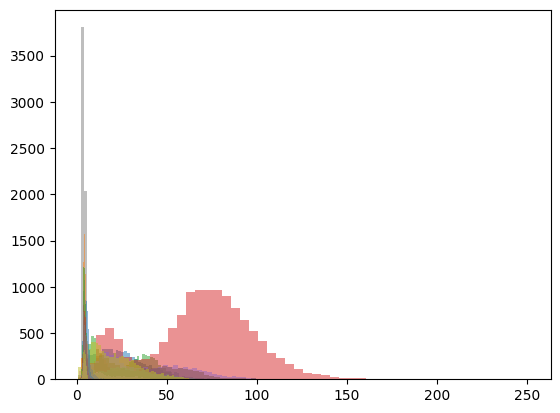

In [10]:
dir = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"
samples = [file for file in os.listdir(dir) if os.path.isdir(os.path.join(dir, file))]
all_data = []

for sample in samples:
    sample_path = os.path.join(dir, sample)
    properties = get_properties(sample_path)
    df = pd.DataFrame({
        "Type": sample.split("\\")[0],
        "Sample": sample.split("\\")[-1],
        "wt_crc_ratio": [properties["wt_crc_ratio"].to_numpy().reshape(-1, 1)],
    })
    plt.hist(properties["raw_CRC"], bins=50, alpha=0.5, label=sample)
    all_data.append(df)

all_data = pd.concat(all_data, ignore_index=True)



In [28]:
dir = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"
samples = [file for file in os.listdir(dir) if os.path.isdir(os.path.join(dir, file))]
test_data = []

for sample in samples:
    ratios = []
    for frame in os.listdir(os.path.join(dir, sample, "properties")):
        if frame.endswith(".csv"):
            df = pd.read_csv(os.path.join(dir, sample, "properties", frame))
            ratio = df["ratio_CRC_WT"].to_numpy().reshape(-1, 1)
            ratios.append(ratio)
    sample_data = pd.DataFrame(
        {
            "Type": sample.split("_")[0],
            "Sample": sample.split("\\")[-1],
            "wt_crc_ratio": [np.vstack(ratios)],
        }
    )
    test_data.append(sample_data)
test_data = pd.concat(test_data, ignore_index=True)

In [29]:
test_data

,Type,Sample,wt_crc_ratio
0,CRC,CRC_s39,"[[6.4525331199290274], [10.17207932915046], [1..."
1,CRC,CRC_s41,"[[12.14760873831946], [9.712802436820349], [8...."
2,CRC,CRC_s89,"[[14.81228774303985], [2.8290594773176214], [1..."
3,CRC,CRC_s90,"[[10.444493142699812], [14.7638207222408], [1...."
4,CRC,CRC_s91,"[[15.349572127281242], [21.11145395410992], [1..."
5,CRC,CRC_s92,"[[1.6860984608780134], [3.1424652662339256], [..."
6,MIX,MIX_s47,"[[0.0184236409593647], [0.6319194895446282], [..."
7,MIX,MIX_s48,"[[1.859528094324856], [0.0149560600822615], [0..."
8,MIX,MIX_s52,"[[4.292443930091538], [3.39485706645893], [9.9..."
9,WT,WT_s66,"[[0.0201651958281705], [0.0541158788917258], [..."


Type: CRC, Sample: CRC_s39
  → Standard Deviation: 0.2841
WT cells: 0.00%
CRC cells: 100.00%


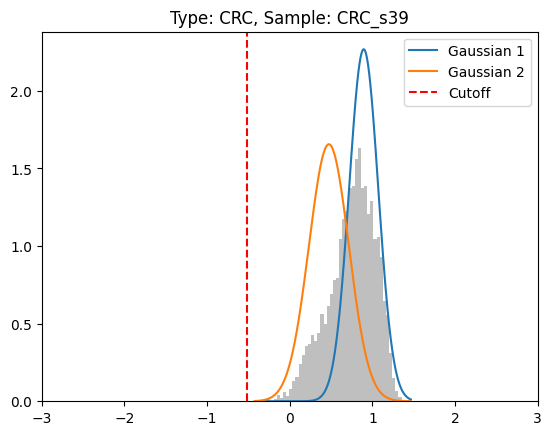

Type: CRC, Sample: CRC_s41
  → Standard Deviation: 0.2200
WT cells: 0.00%
CRC cells: 100.00%


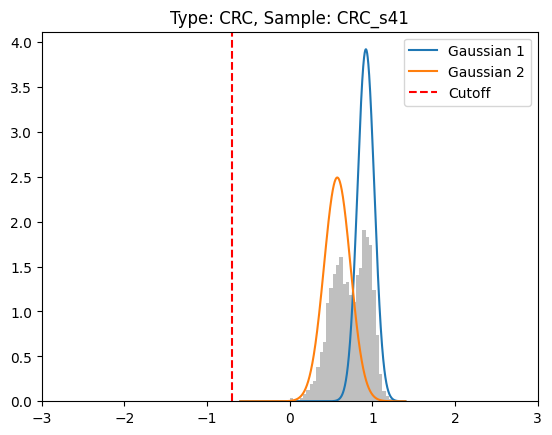

Type: CRC, Sample: CRC_s89
  → Standard Deviation: 0.2851
WT cells: 0.00%
CRC cells: 100.00%


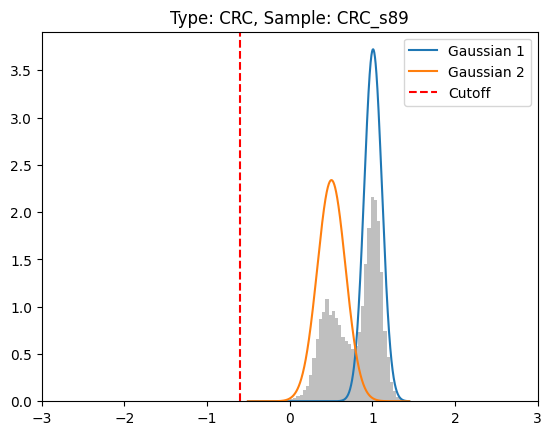

Type: CRC, Sample: CRC_s90
  → Standard Deviation: 0.2630
WT cells: 0.00%
CRC cells: 100.00%


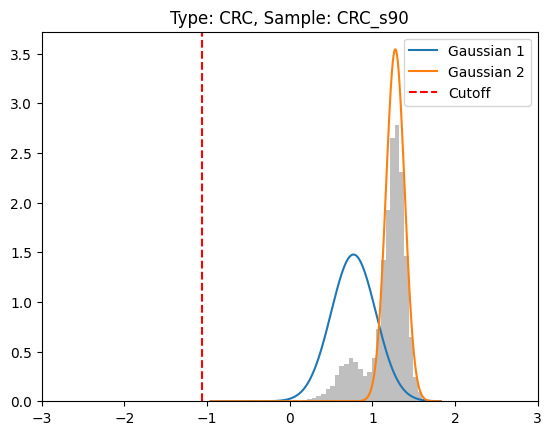

Type: CRC, Sample: CRC_s91
  → Standard Deviation: 0.2956
WT cells: 0.00%
CRC cells: 100.00%


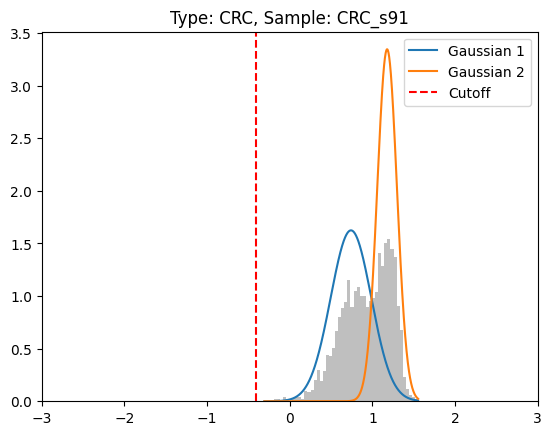

Type: CRC, Sample: CRC_s92
  → Standard Deviation: 0.2985
WT cells: 0.00%
CRC cells: 100.00%


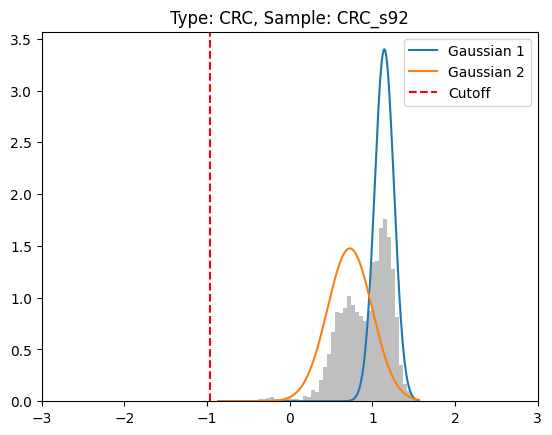

Type: MIX, Sample: MIX_s47
  → Standard Deviation: 1.0852
WT cells: 33.74%
CRC cells: 66.26%


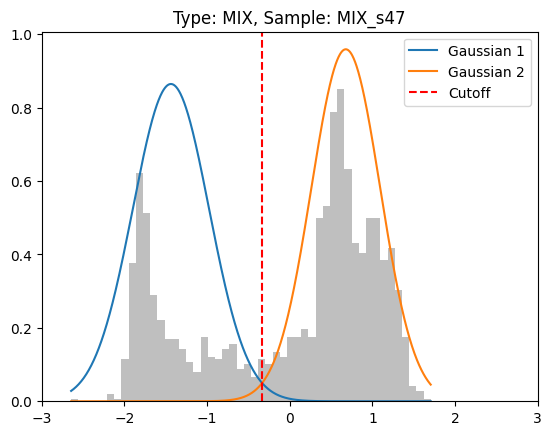

Type: MIX, Sample: MIX_s48
  → Standard Deviation: 1.6864
WT cells: 66.83%
CRC cells: 33.17%


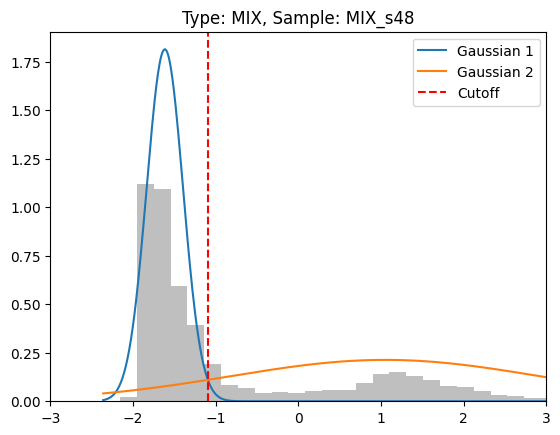

Type: MIX, Sample: MIX_s52
  → Standard Deviation: 0.7072
WT cells: 9.24%
CRC cells: 90.76%


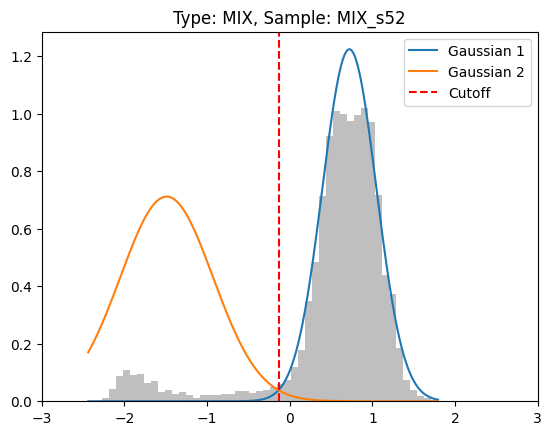

Type: WT, Sample: WT_s66
  → Standard Deviation: 0.2065
WT cells: 100.00%
CRC cells: 0.00%


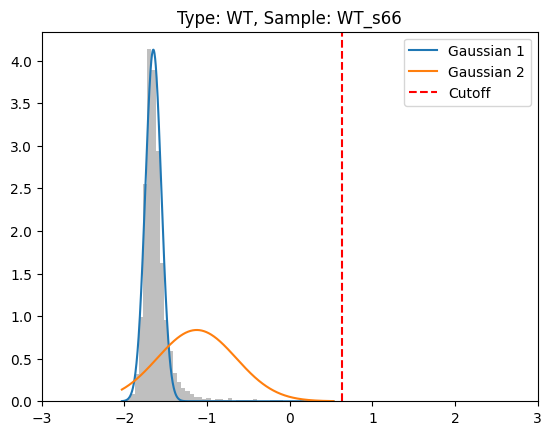

Type: WT, Sample: WT_s67
  → Standard Deviation: 0.1541
WT cells: 100.00%
CRC cells: 0.00%


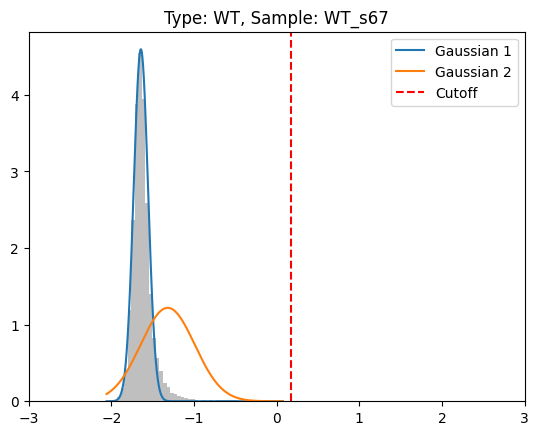

Type: WT, Sample: WT_s69
  → Standard Deviation: 0.1876
WT cells: 100.00%
CRC cells: 0.00%


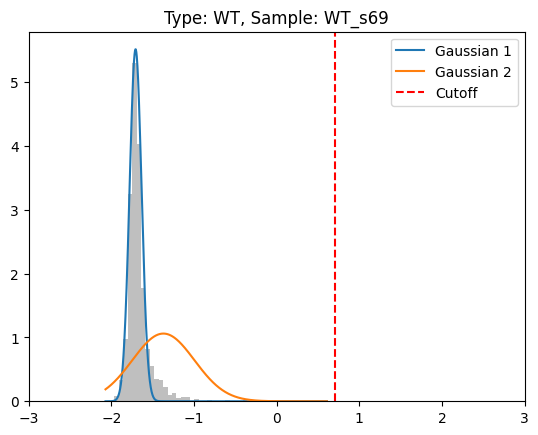

Type: WT, Sample: WT_s70
  → Standard Deviation: 0.2263
WT cells: 100.00%
CRC cells: 0.00%


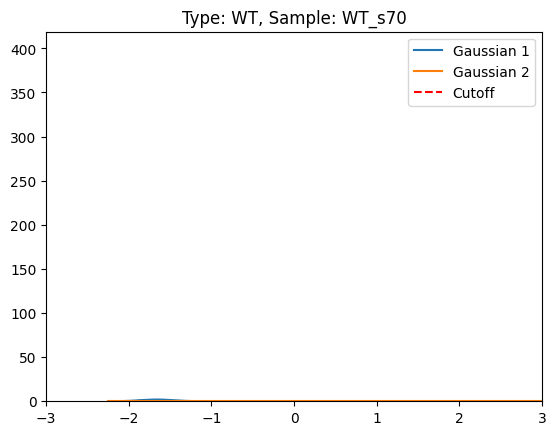

Type: WT, Sample: WT_s71
  → Standard Deviation: 0.1613
WT cells: 100.00%
CRC cells: 0.00%


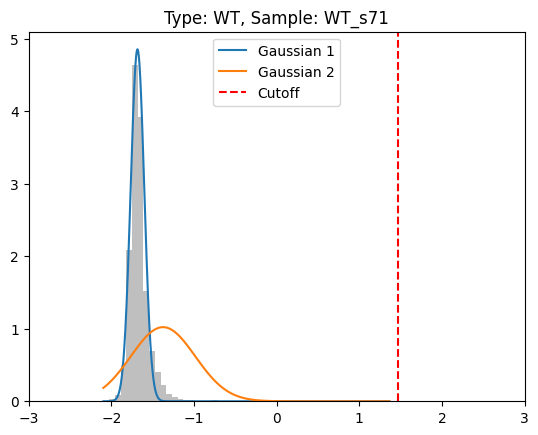

Type: WT, Sample: WT_s73
  → Standard Deviation: 0.1796
WT cells: 100.00%
CRC cells: 0.00%


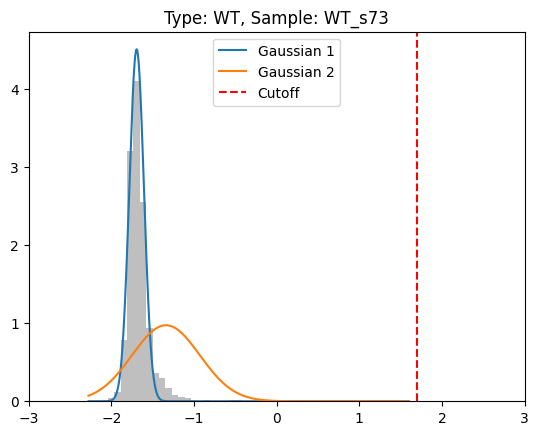

Type: WT, Sample: WT_s74
  → Standard Deviation: 0.2338
WT cells: 100.00%
CRC cells: 0.00%


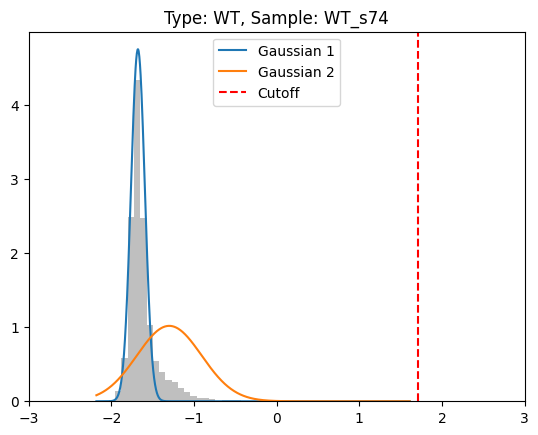

Type: WT, Sample: WT_s75
  → Standard Deviation: 0.2258
WT cells: 100.00%
CRC cells: 0.00%


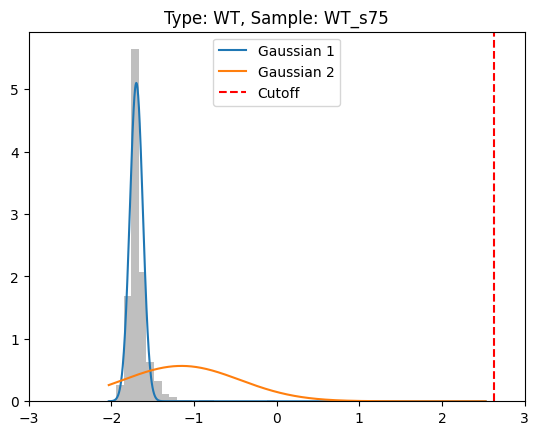

Type: WT, Sample: WT_s76
  → Standard Deviation: 0.1543
WT cells: 100.00%
CRC cells: 0.00%


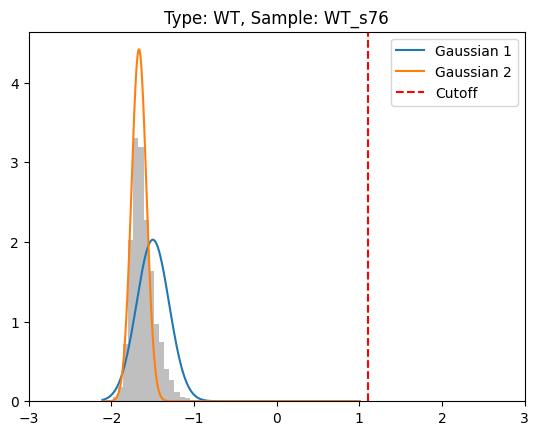

Type: WT, Sample: WT_s78
  → Standard Deviation: 0.1671
WT cells: 100.00%
CRC cells: 0.00%


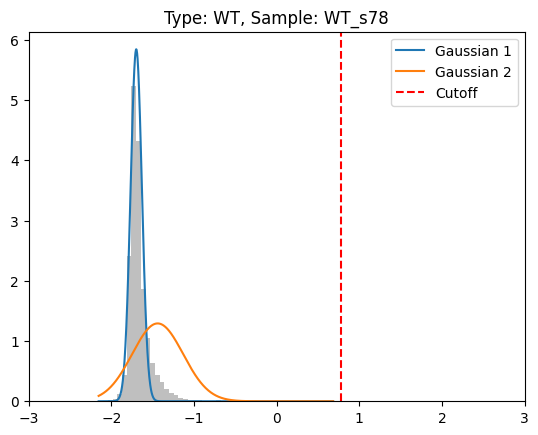

In [ ]:
import scipy

# found online
def solve_gasussians(m1, s1, m2, s2):
    a = 1.0/(2.0*s1**2) - 1.0/(2.0*s2**2)
    b = m2/(s2**2) - m1/(s1**2)
    c = m1**2 /(2*s1**2) - m2**2 / (2.0*s2**2) - np.log(s2/s1)
    return np.roots([a,b,c])

def plot_gaussians(data):
    # Assuming data is already in shape (-1, 1)
    gmm = GaussianMixture(n_components=2, init_params='kmeans', random_state=0)
    gmm.fit(data)

    # Access the means of the Gaussian components
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    # Use the means and stds from your GMM
    mu1, mu2 = means
    sigma1, sigma2 = stds
    x_vals = np.linspace(data.min(), data.max(), 1000)
    pdf1 = norm(mu1, sigma1).pdf(x_vals)
    pdf2 = norm(mu2, sigma2).pdf(x_vals)

    if np.std(data) > 0.7: # High SD, so it is a mixed sample
        # Make two gaussian distributions on the data and 
        # calculate the intersection
        solved_val = solve_gasussians(mu1, sigma1, mu2, sigma2)
        cutoff = solved_val[1]

    elif data.mean() > 0: # Means this sample is pure CRC
        cutoff = data.min() - 0.1

    elif data.mean() <= 0: # Means this sample is pure WT   
        cutoff = data.max() + 0.1

    print(f"WT cells: {np.sum(data.flatten() < cutoff) / len(data.flatten()) * 100:.2f}%")
    print(f"CRC cells: {np.sum(data.flatten() >= cutoff) / len(data.flatten()) * 100:.2f}%")

    # Plot as before
    plt.hist(data, bins=50, density=True, alpha=0.5, color="gray")
    x_vals = np.linspace(data.min(), data.max(), 1000)
    pdf1 = norm(mu1, sigma1).pdf(x_vals)
    pdf2 = norm(mu2, sigma2).pdf(x_vals)
    plt.plot(x_vals, pdf1, label="Gaussian 1")
    plt.plot(x_vals, pdf2, label="Gaussian 2")
    plt.axvline(cutoff, color="red", linestyle="--", label="Cutoff")
    plt.xlim(-3, 3)
    plt.legend()
    plt.show()

for _, sample in test_data.iterrows():
    raw_ratios = [item[0] for item in sample["wt_crc_ratio"]]
    data = np.log10(np.array(raw_ratios) + 1e-6).reshape(-1, 1)
    #data = np.array(raw_ratios).reshape(-1, 1)  # Ensure data is in the correct shape for GaussianMixture
    print(f"Type: {sample['Type']}, Sample: {sample['Sample']}")

    std_dev = np.std(data)
    variance = np.var(data)
    print(f"  → Standard Deviation: {std_dev:.4f}")
    #print(f"  → Variance: {variance:.4f}")

    plt.title(f"Type: {sample['Type']}, Sample: {sample['Sample']}")
    plot_gaussians(data)

In [34]:
output_directory = r"E:\demo_data"
import shutil

for sample in samples:
    props = [file for file in os.listdir(os.path.join(dir, sample, "properties")) if file.endswith(".csv")]

    os.makedirs(os.path.join(output_directory, sample), exist_ok=True)
    os.makedirs(os.path.join(output_directory, sample, "properties"), exist_ok=True)
    for prop in props:
        src = os.path.join(dir, sample, "properties", prop)
        dst = os.path.join(output_directory, sample, "properties", prop)
        shutil.copyfile(src, dst)


In [90]:
for _, sample in all_data.iterrows():
    raw_ratios = [item[0] for item in sample["raw_CRC"]]
    data = np.log10(np.array(raw_ratios) + 0.1).reshape(-1, 1)
    #data = np.array(raw_ratios).reshape(-1, 1)
    plt.hist(data, bins=50, alpha=0.5, label=sample["Sample"])
    plt.yscale("log")  # Make y-axis logarithmic
    #plt.xlim(0,500)
    plt.legend()


KeyError: 'raw_CRC'

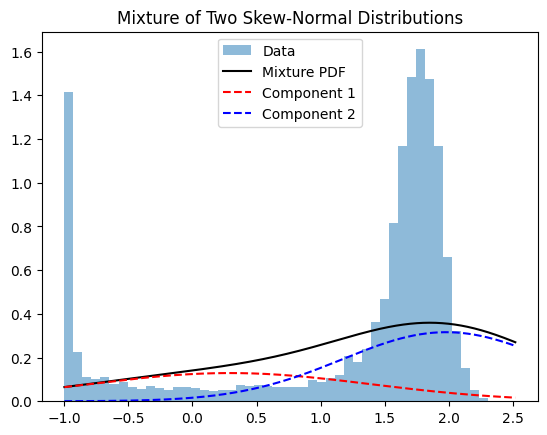

In [76]:
import numpy as np
from scipy.stats import skewnorm
from scipy.optimize import minimize


def skewnorm_mixture_pdf(x, params):
    # Unpack parameters
    w, a1, loc1, scale1, a2, loc2, scale2 = params
    w = np.clip(w, 0, 1)  # Ensure weight is between 0 and 1

    # Component PDFs
    pdf1 = skewnorm.pdf(x, a1, loc=loc1, scale=scale1)
    pdf2 = skewnorm.pdf(x, a2, loc=loc2, scale=scale2)

    return w * pdf1 + (1 - w) * pdf2


def neg_log_likelihood(params, x):
    pdf_vals = skewnorm_mixture_pdf(x, params)
    # Avoid log(0) by clipping
    pdf_vals = np.clip(pdf_vals, 1e-10, None)
    return -np.sum(np.log(pdf_vals))

# sample = pure
sample = np.log10(mixed_ratio + 0.1)

# Initial guess: [weight, a1, loc1, scale1, a2, loc2, scale2]
init_params = [0.5, 0, np.mean(sample) - 1, 1, 0, np.mean(sample) + 1, 1]

result = minimize(neg_log_likelihood, init_params, args=(sample,), method="L-BFGS-B")
params_fit = result.x

import matplotlib.pyplot as plt

# Unpack fitted parameters
w, a1, loc1, scale1, a2, loc2, scale2 = params_fit

# Generate x values
x_vals = np.linspace(sample.min(), sample.max(), 1000)

# Individual component PDFs
pdf1 = skewnorm.pdf(x_vals, a1, loc=loc1, scale=scale1)
pdf2 = skewnorm.pdf(x_vals, a2, loc=loc2, scale=scale2)

# Total mixture PDF
pdf_mix = w * pdf1 + (1 - w) * pdf2

# Plot
plt.hist(sample, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x_vals, pdf_mix, "k-", label="Mixture PDF")
plt.plot(x_vals, w * pdf1, "r--", label="Component 1")
plt.plot(x_vals, (1 - w) * pdf2, "b--", label="Component 2")
plt.title("Mixture of Two Skew-Normal Distributions")
plt.legend()
plt.show()

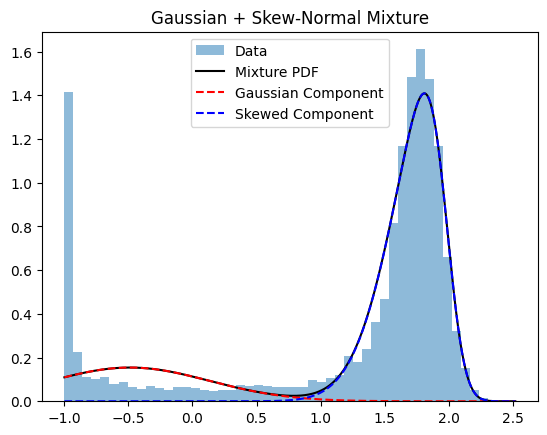

In [77]:
from scipy.stats import norm, skewnorm


def gaussian_skewnorm_mixture_pdf(x, params):
    # Unpack parameters
    w, mu1, sigma1, a2, loc2, scale2 = params
    w = np.clip(w, 0, 1)

    # Component PDFs
    pdf1 = norm.pdf(x, loc=mu1, scale=sigma1)
    pdf2 = skewnorm.pdf(x, a2, loc=loc2, scale=scale2)

    return w * pdf1 + (1 - w) * pdf2


def neg_log_likelihood(params, x):
    pdf_vals = gaussian_skewnorm_mixture_pdf(x, params)
    pdf_vals = np.clip(pdf_vals, 1e-10, None)  # Avoid log(0)
    return -np.sum(np.log(pdf_vals))

sample = np.log10(mixed_ratio + 0.1)

# Initial guess: [weight, mu1, sigma1, a2, loc2, scale2]
init_params = [0.5, np.mean(sample) - 1, 1, 5, np.mean(sample) + 1, 1]

from scipy.optimize import minimize

bounds = [
    (0.05, 0.95),        # weight: avoid extreme dominance
    (-2.0, 0.0),         # mu1: Gaussian mean near the peak (~−1.75)
    (0.3, 2.5),          # sigma1: allow moderate spread
    (-10.0, 10.0),       # a2: skewness, full range
    (0.0, 2.5),          # loc2: skewed component center (tail region)
    (0.3, 3.0)           # scale2: allow wider tail modeling
]

result = minimize(neg_log_likelihood, init_params, args=(sample,), method="L-BFGS-B", bounds= bounds)
params_fit = result.x

x_vals = np.linspace(sample.min(), sample.max(),1000)

# Unpack fitted parameters
w, mu1, sigma1, a2, loc2, scale2 = params_fit

pdf1 = norm.pdf(x_vals, loc=mu1, scale=sigma1)
pdf2 = skewnorm.pdf(x_vals, a2, loc=loc2, scale=scale2)
pdf_mix = w * pdf1 + (1 - w) * pdf2

plt.hist(sample, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x_vals, pdf_mix, "k-", label="Mixture PDF")
plt.plot(x_vals, w * pdf1, "r--", label="Gaussian Component")
plt.plot(x_vals, (1 - w) * pdf2, "b--", label="Skewed Component")
plt.title("Gaussian + Skew-Normal Mixture")
plt.legend()
plt.show()

In [68]:
samples = [pure, mixed]

for sample in samples:
    threshold = np.percentile(sample, 99)
    top_5_percent = sample[sample > threshold]

    print(f"sample {top_5_percent.mean()}")

sample -0.03592474489131749
sample 2.0605038696144056


In [51]:
from scipy.stats import norm, skewnorm
from scipy.integrate import quad

# Extract parameters
weight = params_fit[0]
mu1, sigma1 = params_fit[1], params_fit[2]
a2, loc2, scale2 = params_fit[3], params_fit[4], params_fit[5]

# Define Gaussian support region (e.g. ±2σ)
gauss_lower = mu1 - 2 * sigma1
gauss_upper = mu1 + 2 * sigma1

# Define skewed PDF
def skew_pdf(x):
    return skewnorm.pdf(x, a2, loc2, scale2)

# Total area under skewed component (should be ~1)
total_area = quad(skew_pdf, -np.inf, np.inf)[0]

# Area of skewed component within Gaussian support
overlap_area = quad(skew_pdf, gauss_lower, gauss_upper)[0]

# Percentage overlap
overlap_percent = 100 * overlap_area / total_area
print(f"Overlap of skewed component within Gaussian support: {overlap_percent:.2f}%")

Overlap of skewed component within Gaussian support: 33.77%


In [ ]:
summary_results = []
for number in range():
    df = properties[properties["file"] == number]
    crc_count = np.sum(df["log_ratio"] < cutoff)
    wt_count = np.sum(df["log_ratio"] >= cutoff)
    total = crc_count + wt_count

    results = {
        "file": number,
        "wt_count": wt_count,
        "crc_count": crc_count,
        "%wt": wt_count / total * 100,
        "%crc": crc_count / total * 100,
    }
    summary_results.append(pd.DataFrame([results]))

summary_results = pd.concat(summary_results, ignore_index=True)

    file  wt_count  crc_count        %wt       %crc
0      0       158         11  93.491124   6.508876
1      1       201          8  96.172249   3.827751
2      2       258         15  94.505495   5.494505
3      3       299         15  95.222930   4.777070
4      4       390          8  97.989950   2.010050
5      5       423         47  90.000000  10.000000
6      6       543         41  92.979452   7.020548
7      7       609         57  91.441441   8.558559
8      8       758         63  92.326431   7.673569
9      9       849         70  92.383025   7.616975
10    10       901         97  90.280561   9.719439
11    11      1034        107  90.622261   9.377739
12    12      1083        183  85.545024  14.454976
13    13      1338        174  88.492063  11.507937


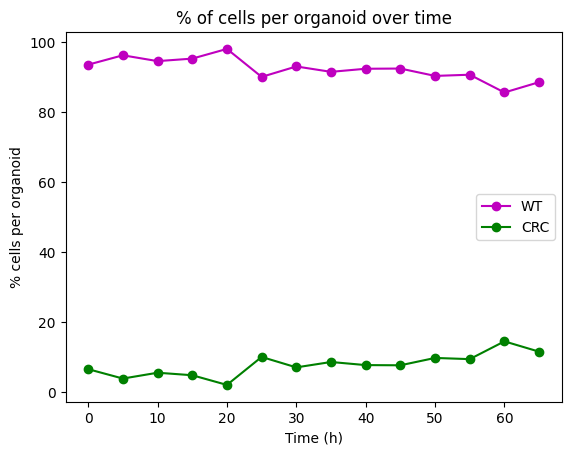

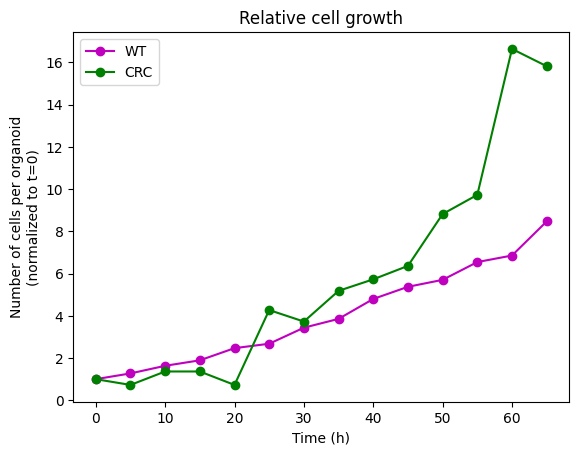

In [19]:
import matplotlib.pyplot as plt
print(summary_results)

# plot 1
plt.plot(summary_results["file"]*5, summary_results["%wt"], "m-", marker = "o", label = "WT")
plt.plot(summary_results["file"]*5, summary_results["%crc"], "g-", marker = "o", label = "CRC")

plt.title("% of cells per organoid over time")
plt.ylabel("% cells per organoid")
plt.xlabel("Time (h)")
plt.legend()

plt.show()

# plot 2
relative_wt = summary_results["wt_count"] / summary_results["wt_count"][0]
relative_crc = summary_results["crc_count"] / summary_results["crc_count"][0]

plt.plot(summary_results["file"] * 5, relative_wt, "m-", marker="o", label="WT")
plt.plot(summary_results["file"] * 5, relative_crc, "g-", marker="o", label="CRC")

plt.title("Relative cell growth")
plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
plt.xlabel("Time (h)")
plt.legend()

plt.show()

In [24]:
import os
import re
import tifffile

input = r"C:\Users\6331823\Local SSD\Data_Anna\s65\s65.tif"
image = tifffile.imread(input)
print(image.shape)

input1 = r"C:\Users\6331823\Local SSD\Data_Anna\s55\s55.tif"
image1 = tifffile.imread(input1)
print(image1.shape)

(15, 3, 61, 1024, 1024)
(15, 61, 3, 1024, 1024)


In [ ]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\mixed\EXpansionLMix_12"

segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1
all_ratios = []
frame_data = []

for file in range(15):
    segmented_stack = tifffile.imread(
        os.path.join(segmented, f"Frame-{file}_masks.tif")
    )
    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    # threshold = frame_WT.copy()
    # threshold = utils.threshold(threshold)
    # blurred = ndimage.gaussian_filter(threshold, sigma=(0, 2, 2))

    median_value = np.median(frame_WT[frame_WT > 0])
    offset_image = frame_WT.astype(np.float32) - median_value
    offset_image[offset_image < 0] = 0  # Clip negative values
    offset_image = np.clip(offset_image, 0, 255).astype(np.uint16)
    df_wt = utils.properties_channel(segmented_stack, offset_image, "WT")

    frame_CRC = frame[CRC_channel, :, :, :]
    df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final["file"] = file
    df_final["wt_crc_ratio"] = df_final.apply(
        lambda row: row["raw_WT"] / row["raw_CRC"] if row["raw_CRC"] != 0 else 5, axis=1
    )

    frame_data.append(df_final)

properties = pd.concat(frame_data, ignore_index=True)
print(properties)
ratios = properties["wt_crc_ratio"]

      label          z           y           x                  bounding_box  \
0         1   7.127551   46.301020   76.003401        (6, 37, 65, 9, 56, 85)   
1         2   6.462810   61.421488   48.839669        (6, 51, 39, 8, 75, 59)   
2         3   7.107450   67.340974   91.563037       (6, 58, 82, 9, 78, 103)   
3         4   7.208931   71.119617   68.886762        (6, 61, 59, 9, 81, 78)   
4         5   7.191077   96.287100   90.289040      (6, 84, 80, 9, 109, 103)   
...     ...        ...         ...         ...                           ...   
7818   1228  56.543103  558.685345  323.349138  (56, 551, 318, 58, 566, 331)   
7819   1229  56.388889  563.370370  333.438272  (56, 557, 327, 58, 571, 339)   
7820   1230  57.000000  419.983871  539.193548  (57, 413, 533, 58, 428, 545)   
7821   1231  57.000000  441.805369  519.281879  (57, 435, 513, 58, 449, 527)   
7822   1232  57.000000  537.000000  447.500000  (57, 533, 444, 58, 542, 452)   

      volume  area_WT     raw_WT  area_

In [15]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.ndimage as ndimage

In [ ]:
channel_names = ["WT","CRC","Test","Nuclei"]

# Extract channel indices with a dictionary for dynamic access
channel_indices = {ch.lower(): i for i, ch in enumerate(channel_names) if ch.strip()}

# Always process the nuclei channel
nuclei_index = channel_indices.get("nuclei", -1)
if nuclei_index == -1:
    raise ValueError("Nuclei channel is required.")

# Placeholder for channel dataframes
channel_dfs = {}

for ch_name, ch_index in channel_indices.items():
    if ch_name == "nuclei":
        continue  # Skip nuclei for separate processing or if handled elsewhere

    # frame_ch = frame[ch_index, :, :, :]
    # offset_ch = utils.offset_image(frame_ch, type="median")
    # df_ch = utils.properties_channel(segmented_stack, offset_ch, channel_names[ch_index])
    # channel_dfs[ch_name.upper()] = df_ch

    print(ch_index, channel_names[ch_index])



0 WT
1 CRC
2 Test


TypeError: index expected at least 1 argument, got 0

In [3]:
import utils
import napari
from scipy.ndimage import gaussian_filter
from scipy.signal import wiener
import tifffile



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.7.1+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


In [11]:
input = r"C:\Users\6331823\Local SSD\Data_Anna\s65\cropped\Frame-14.tif"

WT_channel = 0
CRC_channel = 1
Nuclei_channel = 2


image = tifffile.imread(input)


image = image[CRC_channel,:,:,:]


threshold = image.copy()

threshold = utils.threshold(threshold)


blurred = gaussian_filter(threshold, sigma=(0, 2, 2))


offset_image = utils.offset_image(image, type="median")


viewer = napari.Viewer()


new_layer = viewer.add_image(image)


new_layer2 = viewer.add_image(threshold)


new_layer2 = viewer.add_image(blurred)


new_layer2 = viewer.add_image(offset_image)

In [ ]:
import tifffile
import scipy.ndimage as ndimage
from imaris_ims_file_reader.ims import ims
import numpy as np
import random

import os

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\crc"
output_directory = r"C:\Users\6331823\Local SSD\Train model whole organoid segmentation"

for file in os.listdir(input_directory):
    if file.endswith(".tif"):
        max_data = tifffile.imread(os.path.join(input_directory, file))
        max_data = max_data[:,:,2,:,:] # T Z X Y
        max_data = np.max(max_data, axis=1) # T X Y
        frames = random.sample(range(0, max_data.shape[0]), 4)

        for frame_n in frames:
            frame = max_data[frame_n,:,:]
            resize_factors = (200 / frame.shape[0], 200 / frame.shape[1])
            print(frame.shape)
            XY = ndimage.zoom(frame, resize_factors, order=0)
            XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
            tifffile.imwrite(
                f"{os.path.join(output_directory,file.split('.')[0])}-{frame_n}_small.tif", XY
            )

In [3]:
import re
test = pd.read_csv(r"C:\Users\6331823\Local SSD\Data_Anna\all\summary_results.csv")

def classify_type(organoid):
    if "CRC" in organoid:
        return "CRC"
    elif "WT" in organoid:
        return "WT"
    elif "Mix" in organoid:
        return "Mixed"


test["type"] = test["organoid"].apply(classify_type)
test["time"] = test["file"].apply(lambda x: int(re.search(r'\d+', x).group()))
test = test[test["organoid"] != "EXpansionLMix_14"]

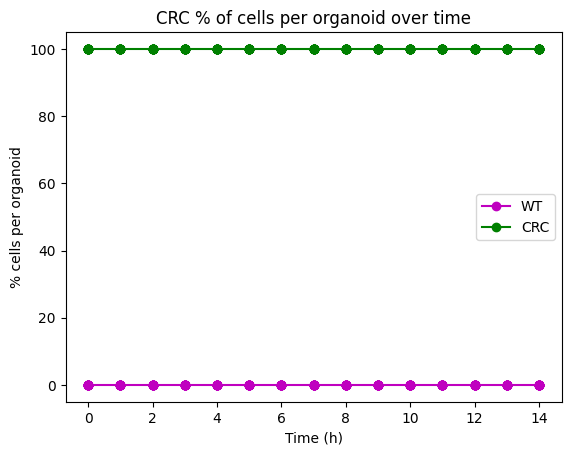

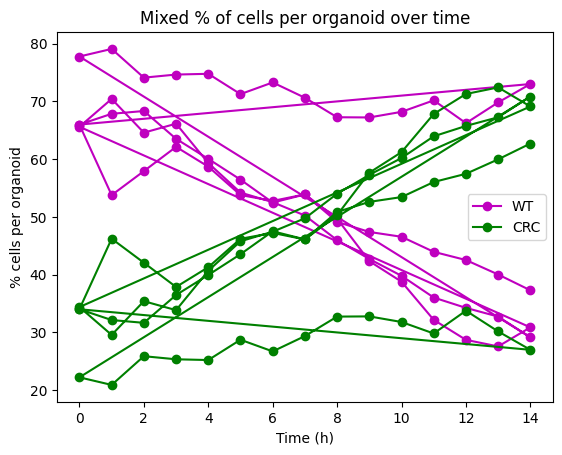

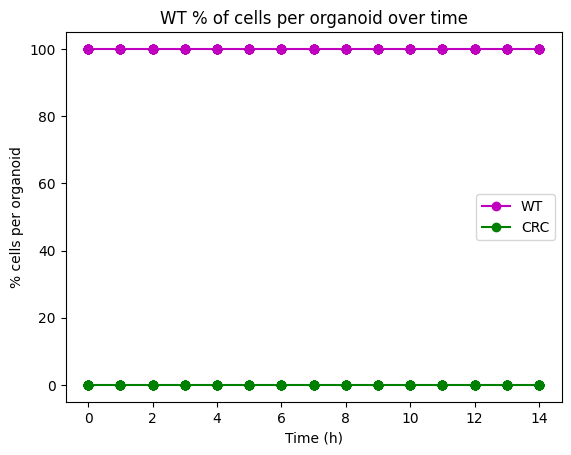

In [4]:
for type in test["type"].unique():
    data = test[test["type"] == type]
    
    plt.plot(data["time"], data["%wt"], "m-", marker="o", label="WT")
    plt.plot(data["time"], data["%crc"], "g-", marker="o", label="CRC")
    plt.title(f"{type} % of cells per organoid over time")
    plt.ylabel("% cells per organoid")
    plt.xlabel("Time (h)")
    plt.legend()
    plt.show()


In [27]:
print(test["type"].unique())
for type in data["type"].unique():
    data = test[test["type"] == type]
# WT relative growth
    plt.plot(data["time"], data["relative_wt"], "m-", marker="o", label="WT")
    plt.title(f"Sample:{type}, WT relative cell growth")
    plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
    plt.xlabel("Time (h)")
    plt.legend()
    plt.show()


    # CRC relative growth
    plt.plot(data["time"], data["relative_crc"], "g-", marker="o", label="CRC")
    plt.title("CRC relative cell growth")
    plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
    plt.xlabel("Time (h)")
    plt.legend()
    plt.show()

NameError: name 'test' is not defined

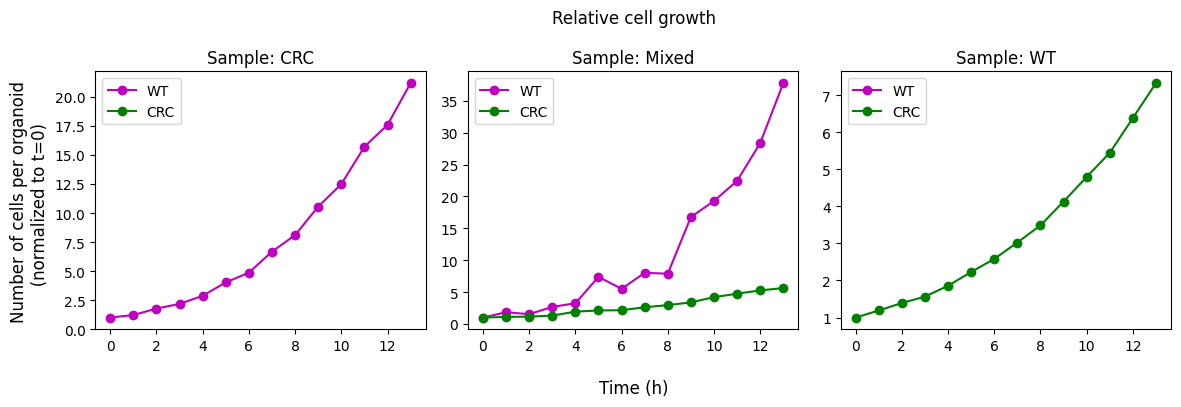

In [48]:
new = data.groupby(["type","time"])[["%wt", "%crc", "relative_wt","relative_crc"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

for i, type in enumerate(new["type"].unique()):
    to_plot = new[new["type"] == type]
    # WT relative growth
    ax = axes[i]
    ax.plot(to_plot["time"], to_plot["relative_wt"], "m-", marker="o", label="WT")
    ax.plot(to_plot["time"], to_plot["relative_crc"], "g-", marker="o", label="CRC")
    ax.set_title(f"Sample: {type}") 
    ax.set_xticks(to_plot["time"][::2])
    ax.legend()


fig.suptitle(f"Relative cell growth", x = 0.54)
fig.supylabel("Number of cells per organoid\n       (normalized to t=0)")
fig.supxlabel("Time (h)", x = 0.54)
plt.tight_layout()
plt.show()

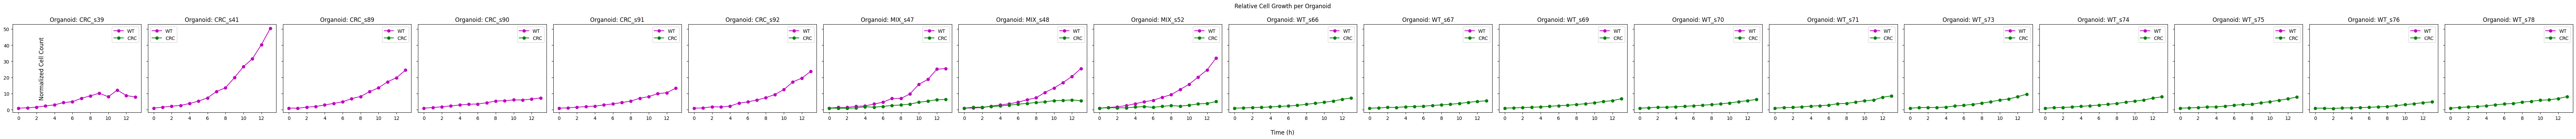

In [52]:
# Group by organoid and time to preserve individual traces
organoid_data = (
    data.groupby(["organoid", "time"])[["relative_wt", "relative_crc"]]
    .mean()
    .reset_index()
)

# Get unique organoids
organoids = organoid_data["organoid"].unique()

# Create subplots: one per organoid
fig, axes = plt.subplots(
    1, len(organoids), figsize=(4 * len(organoids), 4), sharey=True
)

# If only one organoid, axes won't be iterable
if len(organoids) == 1:
    axes = [axes]

for ax, organoid in zip(axes, organoids):
    to_plot = organoid_data[organoid_data["organoid"] == organoid]
    ax.plot(to_plot["time"], to_plot["relative_wt"], "m-", marker="o", label="WT")
    ax.plot(to_plot["time"], to_plot["relative_crc"], "g-", marker="o", label="CRC")
    ax.set_title(f"Organoid: {organoid}")
    ax.set_xticks(to_plot["time"][::2])
    ax.legend()

fig.suptitle("Relative Cell Growth per Organoid", x=0.5)
fig.supxlabel("Time (h)", x=0.5)
fig.supylabel("Normalized Cell Count")
plt.tight_layout()
plt.show()

C:\Users\6331823\AppData\Local\Temp\ipykernel_24552\1722036845.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  grouped = grouped[data["organoid"] != "CRC_s39"]


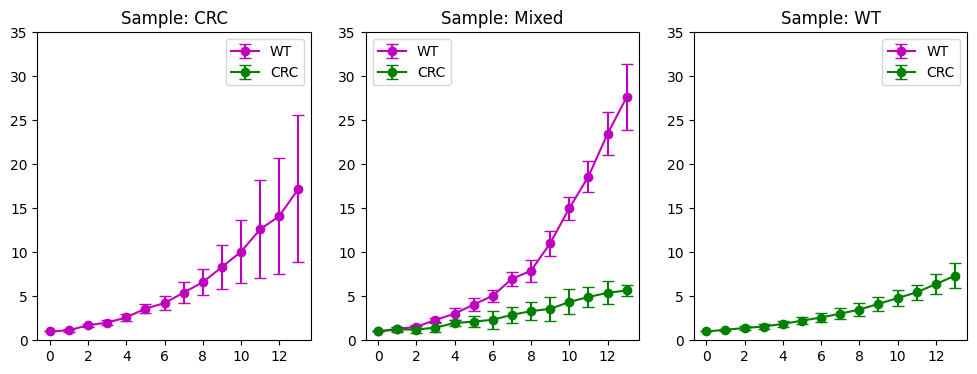

In [64]:
grouped = data[data["organoid"] != "CRC_s41"]
grouped = grouped[data["organoid"] != "CRC_s39"]
grouped = grouped.groupby(["type", "time"])[["relative_wt", "relative_crc"]]
mean = grouped.mean().reset_index()
std = grouped.std().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

for i, type in enumerate(mean["type"].unique()):
    data_mean = mean[mean["type"] == type]
    data_std = std[std["type"] == type]

    ax = axes[i]

    # WT with error bars
    ax.errorbar(
        data_mean["time"],
        data_mean["relative_wt"],
        yerr=data_std["relative_wt"],
        fmt="m-o",
        label="WT",
        capsize=4,
    )

    # CRC with error bars
    ax.errorbar(
        data_mean["time"],
        data_mean["relative_crc"],
        yerr=data_std["relative_crc"],
        fmt="g-o",
        label="CRC",
        capsize=4,
    )

    ax.set_ylim(0,35)
    ax.set_title(f"Sample: {type}")
    ax.set_xticks(data_mean["time"][::2])
    ax.legend()

In [8]:
test["organoid"].unique()

array(['EXpansion_CRC_1', 'EXpansion_CRC_10', 'EXpansion_CRC_11',
       'EXpansion_CRC_12', 'EXpansion_CRC_13', 'EXpansion_CRC_14',
       'EXpansion_CRC_15', 'EXpansion_CRC_3', 'EXpansion_CRC_4',
       'EXpansion_CRC_5', 'EXpansion_CRC_6', 'EXpansion_CRC_7',
       'EXpansion_CRC_8', 'EXpansionLMix_11', 'EXpansionLMix_19',
       'EXpansionLMix_5', 'EXpansionLMix_8', 'EXpansionLWT_Pure_1',
       'EXpansionLWT_Pure_10', 'EXpansionLWT_Pure_11',
       'EXpansionLWT_Pure_12', 'EXpansionLWT_Pure_13',
       'EXpansionLWT_Pure_14', 'EXpansionLWT_Pure_2',
       'EXpansionLWT_Pure_3', 'EXpansionLWT_Pure_4',
       'EXpansionLWT_Pure_5', 'EXpansionLWT_Pure_6',
       'EXpansionLWT_Pure_7', 'EXpansionLWT_Pure_8',
       'EXpansionLWT_Pure_9'], dtype=object)

In [38]:
import napari
import numpy as np
import tifffile
import pandas as pd

import os

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47"

movie = os.path.join(input_directory, "segmented_movie.tif")
movie = tifffile.imread(movie)

timepoints, z, y, x = movie.shape

labeled = []

for timepoint in range(timepoints):
    frame = movie[timepoint]
    props = pd.read_csv(
        os.path.join(input_directory, "properties", f"Frame-{timepoint}_props.csv")
    )
    new_frame = frame.copy()
    for _, row in props.iterrows():
        label_id = row["label"]
        phenotype = row["phenotype"]

        if phenotype == "CRC":
            new_label = 1
        elif phenotype == "WT":
            new_label = 2

        new_frame[frame == label_id] = new_label

    labeled.append(new_frame)

labeled = np.stack(labeled, axis = 0)

In [39]:
from utils.pad_to_shape import pad_to_shape

original = []
max_dims = [0,0,0,0]
for timepoint in range(timepoints):
    frame = tifffile.imread(os.path.join(input_directory, "cropped", f"Frame-{timepoint}.tif"))
    print(frame.shape)
    original.append(frame)

    for i in range(4):
        max_dims[i] = max(max_dims[i], frame.shape[i])
print(max_dims)

padded = [
    pad_to_shape(stack, max_dims) for stack in original
]

padded = np.stack(padded, axis=0)



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.8.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully
(3, 17, 100, 97)
(3, 18, 106, 111)
(3, 22, 112, 118)
(3, 19, 110, 115)
(3, 21, 123, 114)
(3, 21, 135, 126)
(3, 23, 142, 141)
(3, 28, 158, 156)
(3, 26, 180, 167)
(3, 27, 189, 184)
(3, 27, 207, 205)
(3, 32, 220, 226)
(3, 32, 234, 240)
(3, 33, 245, 250)
[3, 33, 245, 250]


In [46]:
contrast = (150,300)
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    padded[:, 0].astype(np.uint16),
    name="nuclei",
    scale=(1, 8, 1, 1),
    colormap="gray",
    blending="additive",
    #contrast_limits=(100,500),
)
viewer.add_image(
    padded[:, 1].astype(np.uint16),
    name="CRC",
    scale=(1, 8, 1, 1),
    colormap="green",
    blending="additive",
    #contrast_limits=contrast,
)
viewer.add_image(
    padded[:, 2].astype(np.uint16),
    name="WT",
    scale=(1, 8, 1, 1),
    colormap="magenta",
    blending="additive",
    #contrast_limits=(120,200),
)
viewer.add_labels(
    labeled,
    scale=(1, 8, 1, 1),
    colormap=["black", "lime", "magenta"],
    blending="additive",
)
collapsed = (movie > 0).astype(int)  # All labeled regions become 1

viewer.add_labels(collapsed, name = "Segmented Nuclei", colormap=["black","blue"], scale=(1, 8, 1, 1), blending = "additive")

<Labels layer 'Segmented Nuclei' at 0x216c01b6e10>

In [20]:
collapsed.shape

(15, 44, 525, 543)

In [38]:
import napari
import numpy as np
from napari_animation import Animation
from napari.layers import Labels

# Create viewer
viewer = napari.Viewer(ndisplay=3)

# Add all layers
viewer.add_image(
    padded[:, 0].astype(np.uint16),
    name="WT",
    scale=(1, 8, 1, 1),
    colormap="magenta",
    blending="additive",
    contrast_limits=(100, 500),
    visible=False,
)

viewer.add_image(
    padded[:, 1].astype(np.uint16),
    name="CRC",
    scale=(1, 8, 1, 1),
    colormap="green",
    blending="additive",
    contrast_limits=(150, 250),
    visible=False,
)

viewer.add_image(
    padded[:, 2].astype(np.uint16),
    name="Nuclei",
    scale=(1, 8, 1, 1),
    colormap="blue",
    blending="additive",
    contrast_limits=(120, 200),
)

viewer.add_labels(
    labeled,
    name = "Labeled",
    scale=(1, 8, 1, 1),
    colormap=["black", "lime", "magenta"],
    blending="additive",
    visible=False,
)

viewer.add_labels(
    collapsed, 
    name = "Segmented Nuclei", 
    colormap=["black","blue"], 
    scale=(1, 8, 1, 1), 
    blending = "additive", 
    visible=False,
    )

# Create animation
animation = Animation(viewer)

n_frames = padded.shape[0]
n_steps = 9  # total keyframes for each direction
original = Labels._update_thumbnail
angle_offset = 0
# Forward sweep
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(
    filename=r"C:\Users\6331823\Downloads\top_left.mp4", fps=30
)

animation = Animation(viewer)
viewer.layers["Segmented Nuclei"].visible = True
viewer.layers["Nuclei"].visible = False

for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(
    filename=r"C:\Users\6331823\Downloads\top_right.mp4", fps=30
)

animation = Animation(viewer)
viewer.layers["WT"].visible = True
viewer.layers["CRC"].visible = True

for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(
    filename=r"C:\Users\6331823\Downloads\bottom_left.mp4", fps=30
)
animation = Animation(viewer)
viewer.layers["Segmented Nuclei"].visible = False
viewer.layers["Labeled"].visible = True
viewer.layers["WT"].visible = False
viewer.layers["CRC"].visible = False
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\bottom_right.mp4", fps=30)


viewer.close_all()

Rendering frames...


100%|██████████| 121/121 [00:05<00:00, 21.44it/s]


Rendering frames...


100%|██████████| 121/121 [00:07<00:00, 16.37it/s]


Rendering frames...


100%|██████████| 121/121 [00:10<00:00, 11.83it/s]


Rendering frames...


100%|██████████| 121/121 [00:05<00:00, 23.82it/s]


RuntimeError: wrapped C/C++ object of type QtViewer has been deleted

In [60]:
import os
import tifffile
import napari
import numpy as np

shift_amount = 63

input_directory = (
    r"Z:\users\5595347\Microscope\From Imaris computer\Processed TL\AKG_Exp137\Raw"
)
output_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"

#samples = [39,41,47,48,52,66,67,69,70,71,73,74,75,76,78,89,90,91,92]
#names = ["CRC","CRC","MIX","MIX","MIX","WT","WT","WT","WT","WT","WT","WT","WT","WT","WT","CRC","CRC","CRC","CRC"]
samples = [70, 71, 73, 74, 75, 76, 78, 89, 90, 91, 92]
names = [
    "WT",
    "WT",
    "WT",
    "WT",
    "WT",
    "WT",
    "WT",
    "CRC",
    "CRC",
    "CRC",
    "CRC",
]

for sample, name in zip(enumerate(samples), enumerate(names)):
    sample = sample[1]
    name = name[1]
    movie = []

    file_name = f"{name}_s{sample}"
    os.makedirs(os.path.join(output_directory, file_name), exist_ok=True)

    for timepoint in range(1,15):
        images = [file 
                for file in os.listdir(input_directory) 
                if f"s{sample}" in file and f"t{timepoint}." in file]

        frame = []

        for image in images:
            if "CSU-445" in image:
                image = tifffile.imread(os.path.join(input_directory, image))
                padded = np.pad(
                    image,
                    ((0, 0), (0, 0), (shift_amount, 0)),
                    mode="constant",
                    constant_values=0,
                )
                image = padded[:, :, :-shift_amount]
            else:
                image = tifffile.imread(os.path.join(input_directory, image))
            frame.append(image)

        frame = np.stack(frame, axis=1)
        movie.append(frame)
    movie = np.stack(movie, axis = 0)
    tifffile.imwrite(
        os.path.join(output_directory, file_name, f"{file_name}.tif"),
        movie,
        shape=movie.shape,
        imagej=True,
        metadata={
            "unit": "um",
            "axes": "TZCYX",
        },
    )
    print(f"saved movie {file_name}")

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'WT_s70.tif'> truncating ImageJ file
  warnings.warn(


saved movie WT_s70


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'WT_s71.tif'> truncating ImageJ file
  warnings.warn(


saved movie WT_s71


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'WT_s73.tif'> truncating ImageJ file
  warnings.warn(


...

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'CRC_s90.tif'> truncating ImageJ file
  warnings.warn(


saved movie CRC_s90


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'CRC_s91.tif'> truncating ImageJ file
  warnings.warn(


saved movie CRC_s91
saved movie CRC_s92


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'CRC_s92.tif'> truncating ImageJ file
  warnings.warn(


In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"

folders = [
    os.path.join(input_directory, folder)
    for folder in os.listdir(input_directory)
    if os.path.isdir(os.path.join(input_directory, folder))
]

data = []
for folder in folders:
    results = pd.read_csv(os.path.join(folder, "summary_results_organoid.csv"))
    data.append(results)

data = pd.concat(data, ignore_index=True)


data["time"] = data["file"].apply(lambda f: int(re.search(r"\d+", f).group()))


def classify_type(organoid):
    if "CRC" in organoid:
        return "CRC"
    elif "WT" in organoid:
        return "WT"
    elif "mix" in organoid.lower():
        return "Mixed"


data["type"] = data["organoid"].apply(classify_type)

In [46]:
data

,organoid,file,wt_count,crc_count,%wt,%crc,relative_wt,relative_crc,time,type
0,CRC_s39,Frame-0.tif,92,0,100.0,0.0,1.000000,NaN,0,CRC
1,CRC_s39,Frame-1.tif,108,0,100.0,0.0,1.173913,NaN,1,CRC
2,CRC_s39,Frame-2.tif,151,0,100.0,0.0,1.641304,NaN,2,CRC
3,CRC_s39,Frame-3.tif,215,0,100.0,0.0,2.336957,NaN,3,CRC
4,CRC_s39,Frame-4.tif,277,0,100.0,0.0,3.010870,NaN,4,CRC
...,...,...,...,...,...,...,...,...,...,...
261,WT_s78,Frame-9.tif,0,423,0.0,100.0,NaN,5.222222,9,WT
262,WT_s78,Frame-10.tif,0,479,0.0,100.0,NaN,5.913580,10,WT
263,WT_s78,Frame-11.tif,0,494,0.0,100.0,NaN,6.098765,11,WT
264,WT_s78,Frame-12.tif,0,561,0.0,100.0,NaN,6.925926,12,WT


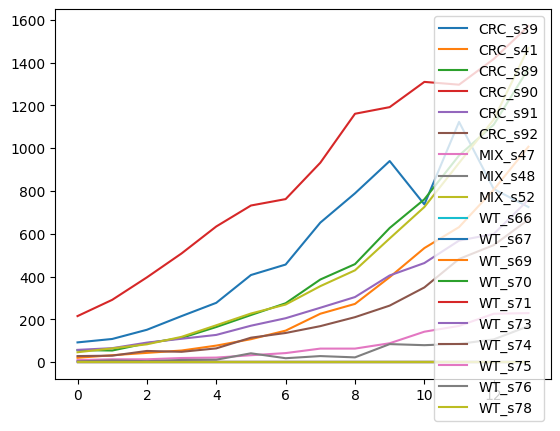

In [ ]:
for sample in data["organoid"].unique():
    to_plot = data[data["organoid"] == sample]

    if to_plot["type"].unique() ==
    plt.plot(to_plot["frame"], to_plot["wt_count"], label = sample)

# plt.legend()
plt.show()

KeyError: 'nearest_other_pheno_dist'

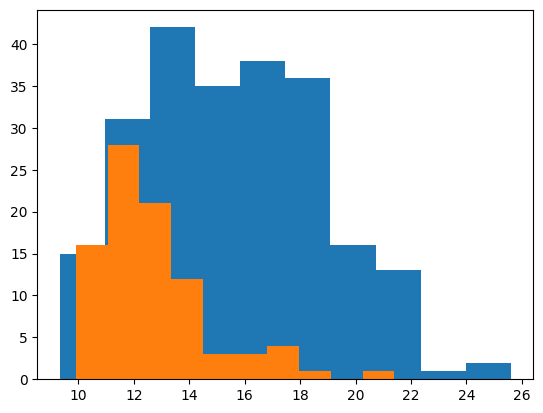

In [3]:
import numpy as np
import sklearn.neighbors as neighbors
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\properties\Frame-13_props.csv"
)

data["new_z"] = data["z"] * 7
test = data[["x","y","new_z"]].to_numpy()
nbrs = neighbors.NearestNeighbors(n_neighbors=5, algorithm="kd_tree").fit(test)
distances, indices = nbrs.kneighbors(test)
mean = [distance.mean() for distance in distances]
data["mean_distance"] = mean
plt.hist(data[data["phenotype"] == "WT"]["mean_distance"])
plt.hist(data[data["phenotype"] == "CRC"]["mean_distance"])
plt.hist(
    data[(data["phenotype"] == "WT") & (data["nearest_other_pheno_dist"] < 10)][
        "mean_distance"
    ],
    alpha=0.6,
)
plt.legend(["CRC","WT"])
plt.show()

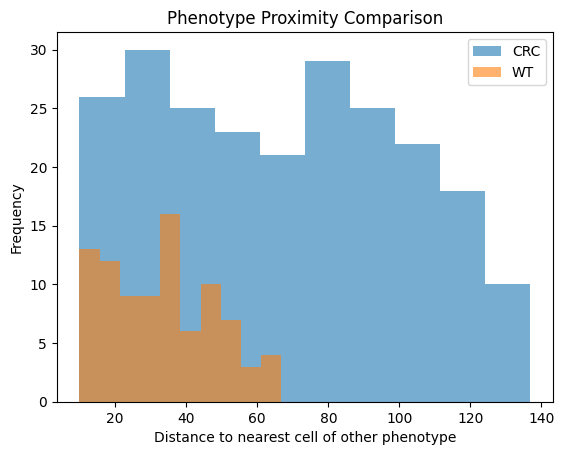

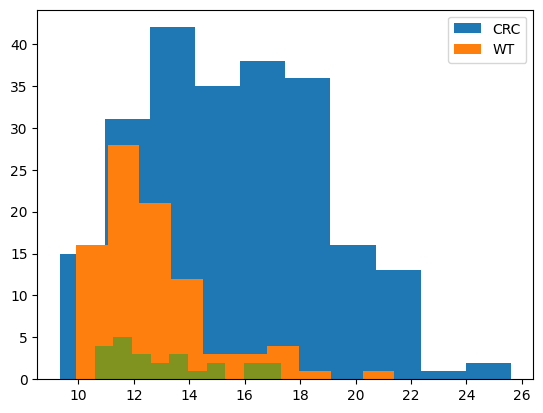

In [4]:
nearest_other_pheno = []

# Loop through each cell
for i, (coord, pheno) in enumerate(zip(test, data["phenotype"])):
    # Filter out cells with the same phenotype
    mask = data["phenotype"] != pheno
    other_coords = test[mask]

    # Fit NearestNeighbors on other phenotype cells
    nbrs = neighbors.NearestNeighbors(n_neighbors=1, algorithm="kd_tree").fit(other_coords)
    distance, _ = nbrs.kneighbors([coord])

    # Store the distance
    nearest_other_pheno.append(distance[0][0])

# Add to DataFrame
data["nearest_other_pheno_dist"] = nearest_other_pheno

# Plot histograms
plt.hist(data[data["phenotype"] == "WT"]["nearest_other_pheno_dist"], alpha=0.6)
plt.hist(data[data["phenotype"] == "CRC"]["nearest_other_pheno_dist"], alpha=0.6)
plt.legend(["CRC", "WT"])
plt.xlabel("Distance to nearest cell of other phenotype")
plt.ylabel("Frequency")
plt.title("Phenotype Proximity Comparison")
plt.show()

nbrs = neighbors.NearestNeighbors(n_neighbors=5, algorithm="kd_tree").fit(test)
distances, indices = nbrs.kneighbors(test)
mean = [distance.mean() for distance in distances]
data["mean_distance"] = mean

plt.hist(data[data["phenotype"] == "WT"]["mean_distance"])
plt.hist(data[data["phenotype"] == "CRC"]["mean_distance"])
plt.hist(
    data[(data["phenotype"] == "WT") & (data["nearest_other_pheno_dist"] < 20)][
        "mean_distance"
    ],
    alpha=0.6,
)
plt.legend(["CRC", "WT"])
plt.show()

In [5]:
from sklearn.neighbors import NearestNeighbors

# Prepare coordinates
coords = data[["x", "y", "new_z"]].to_numpy()
phenotypes = data["phenotype"].to_numpy()

# Fit NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=6, algorithm="kd_tree").fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Skip the first neighbor (it's the cell itself)
neighbor_indices = indices[:, 1:]

# Compute diversity score
diversity_scores = []
for i, neighbors in enumerate(neighbor_indices):
    own_pheno = phenotypes[i]
    neighbor_phenos = phenotypes[neighbors]
    diff_count = sum(neighbor_phenos != own_pheno)
    score = diff_count / len(neighbors)  # Normalize to [0, 1]
    diversity_scores.append(score)

# Add to DataFrame
data["diversity_score"] = diversity_scores

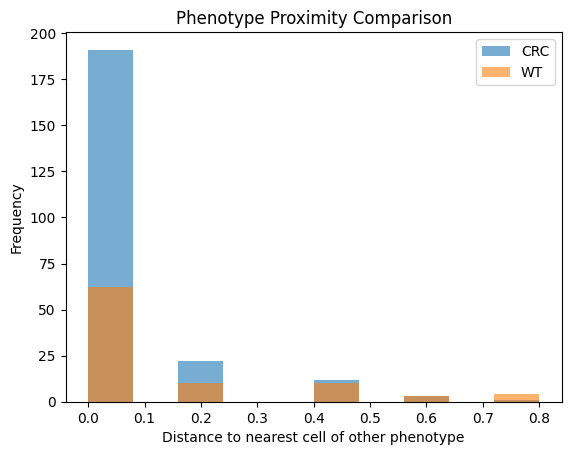

In [6]:
plt.hist(data[data["phenotype"] == "WT"]["diversity_score"], alpha=0.6)
plt.hist(data[data["phenotype"] == "CRC"]["diversity_score"], alpha=0.6)
plt.legend(["CRC", "WT"])
plt.xlabel("Distance to nearest cell of other phenotype")
plt.ylabel("Frequency")
plt.title("Phenotype Proximity Comparison")
plt.show()

In [16]:
import napari
import tifffile
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

image = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\segmented\Frame-13_masks.tif")

properties = {
    "diversity_score": data["diversity_score"].to_numpy(),
    "phenotype": data["phenotype"].to_numpy(),
}

label_ids = data["label"].to_numpy()


# Normalize diversity scores to [0, 1]
norm = Normalize(vmin=0, vmax=1)
cmap = matplotlib.colormaps.get_cmap('viridis')
colors = cmap(norm(data['diversity_score'].to_numpy()))

# Build color dict: label ID → RGB
color_dict = {int(label): tuple(color[:3]) for label, color in zip(data['label'], colors)}

# Launch napari viewer
viewer = napari.Viewer()

# Add label image
labels_layer = viewer.add_labels(image, name='Cell Masks')

# Apply custom colors
labels_layer.color = color_dict

napari.run()

NameError: name 'matplotlib' is not defined

In [43]:
import imaris_ims_file_reader.ims as ims
import numpy as np
import h5py
import hdf5plugin

file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims"
movie = ims(file, ResolutionLevelLock= 0)
print(movie.shape)
t0 = movie[0]
t0 = np.expand_dims(t0, axis=0)
t1 = movie[1:]
movie = np.concatenate([t0, t1], axis=0)

Opening readonly file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

(37, 3, 54, 803, 933)
Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 



In [ ]:
import sys

# test = movie.astype(np.uint8)
# movie_12bit = np.clip(movie, 0, 4095).astype(np.uint16)
full_movie = ims(file,)
print(sys.getsizeof(movie) / 1e9)
print(sys.getsizeof(movie_12bit) / 1e9)
print(sys.getsizeof(test) / 1e9)
print(sys.getsizeof(full_movie) / 1e9)

Opening readonly file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

8.981397788
8.981397788
4.490698982
5.6e-08


In [31]:
import h5py

broken = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims"
file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims"

with h5py.File(broken, "r") as f:

    def print_structure(name, obj):
        print(name)

    f.visititems(print_structure)

DataSet
DataSet/ResolutionLevel 0
DataSet/ResolutionLevel 0/TimePoint 0
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Data
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Histogram
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Histogram1024
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/Data
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/Histogram
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/Histogram1024
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2/Data
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2/Histogram
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2/Histogram1024
DataSet/ResolutionLevel 0/TimePoint 1
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0/Data
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0/Histogram
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0/Histogram1024
DataSe

In [50]:
import h5py


def get_structure(path):
    structure = []
    with h5py.File(path, "r") as f:
        f.visit(lambda name: structure.append(name))
    return set(structure)


# Paths to your files
broken_path = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims"
original_path = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims"

# Get structures
broken_structure = get_structure(broken_path)
original_structure = get_structure(original_path)

# Compare
missing_in_broken = original_structure - broken_structure
extra_in_broken = broken_structure - original_structure

print("🔍 Missing in broken file:")
for item in sorted(missing_in_broken):
    print(item)

print("\n🧪 Extra in broken file:")
for item in sorted(extra_in_broken):
    print(item)

🔍 Missing in broken file:
DataSet/ResolutionLevel 4
DataSet/ResolutionLevel 4/TimePoint 0
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0/Data
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0/Histogram
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0/Histogram1024
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1/Data
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1/Histogram
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1/Histogram1024
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2/Data
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2/Histogram
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2/Histogram1024
DataSet/ResolutionLevel 4/TimePoint 1
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0/Data
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0/Histogram
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0/Hi

In [52]:
file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\testshuffleLZ4.ims"
with h5py.File(original_path, "r") as f:
    dset = f["DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Data"]
    print("Compression:", dset.compression)
    print("Chunks:", dset.chunks)
    print("Shape:", dset.shape)
    print("Dtype:", dset.dtype)

Compression: None
Chunks: (8, 128, 128)
Shape: (64, 1024, 1024)
Dtype: uint16


In [ ]:
from PyImarisWriter import PyImarisWriter as PW
import tables
from alive_progress import alive_bar
from matplotlib.colors import to_rgba
from datetime import datetime
from utils import dummy_callback
import imaris_ims_file_reader.ims as ims
import numpy as np
import tifffile

file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims"
new_movie = tifffile.imread(r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\tif.tif")
movie = ims(file)


output_filename = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\test2.ims"
voxel_size = movie.resolution  # (Z, Y, X)
timepoints = movie.TimePoints
with tables.open_file(file, "r") as hf:
    time_values = hf.root.DataSetTimes.Time.read()
timestamps = np.array([row[2] for row in time_values])
timestamps = timestamps // 1000
channel_colors = ["magenta", "green", "blue"]
channel_names = ["magenta", "green", "blue"]

Z, Y, X, C, T = new_movie.shape

# Create image size
dimension_sequence = PW.DimensionSequence("x", "y", "z", "c", "t")
image_size = PW.ImageSize(x=X, y=Y, z=Z, c=C, t=T)
block_size = PW.ImageSize(x=X, y=Y, z=1, c=1, t=1)
sample_size = PW.ImageSize(x=1, y=1, z=1, c=1, t=1)
image_extents = PW.ImageExtents(
    0.0, 0.0, 0.0, voxel_size[2] * X, voxel_size[1] * Y, voxel_size[0] * Z
)

# Compression
options = PW.Options()
options.mNumberOfThreads = 6
options.mCompressionAlgorithmType = PW.eCompressionAlgorithmLZ4
options.mEnableLogProgress = True

# Dummy progress callback
callback_class = dummy_callback()

# Create converter
converter = PW.ImageConverter(
    "uint16",
    image_size,
    sample_size,
    dimension_sequence,
    block_size,
    output_filename,
    options,
    "OrganoidSegmenter",
    "v1.0",
    callback_class,
)

num_blocks = image_size / block_size
block_index = PW.ImageSize()
total_blocks = Z * C * T

with alive_bar(total_blocks, title="Writing cropped IMS file") as bar:
    for c in range(num_blocks.c):
        block_index.c = c
        for t in range(num_blocks.t):
            block_index.t = t
            for z in range(num_blocks.z):
                block_index.z = z
                z_start = z * block_size.z
                z_end = min(z_start + block_size.z, Z)
                for y in range(num_blocks.y):
                    block_index.y = y
                    y_start = y * block_size.y
                    y_end = min(y_start + block_size.y, Y)
                    for x in range(num_blocks.x):
                        block_index.x = x
                        x_start = x * block_size.x
                        x_end = min(x_start + block_size.x, X)

                        # Extract real voxel block
                        block = new_movie[
                            z_start:z_end, y_start:y_end, x_start:x_end, c, t
                        ]

                        # Reshape to (Z, Y, X, 1, 1) for compatibility
                        block = block[:, :, :, np.newaxis, np.newaxis].astype(
                            np.uint16
                        )

                        if converter.NeedCopyBlock(block_index):
                            converter.CopyBlock(block, block_index)

                        bar()

parameters = PW.Parameters()
for i in range(C):
    parameters.set_channel_name(
        i, channel_names[i] if i < len(channel_names) else f"Channel {i}"
    )
# Time info
time_infos = [datetime.utcfromtimestamp(t / 1e6) for t in timestamps]

# Convert to PW.Color using to_rgba
colors = []
for name in channel_colors:
    try:
        r, g, b, a = to_rgba(name)
        colors.append(PW.Color(r, g, b, a))
    except ValueError:
        print(f"Color '{name}' is not recognized. Using default white.")
        colors.append(PW.Color(1, 1, 1, 1))

# --- Apply colors to ColorInfo objects ---
color_infos = []
for i in range(C):  # assuming C is the number of channels
    ci = PW.ColorInfo()
    if i < len(channel_colors):
        ci.set_base_color(colors[i])
    else:
        ci.set_base_color(PW.Color(1, 1, 1, 1))  # default white for extras
    color_infos.append(ci)

# Finalize writing
converter.Finish(
    image_extents,  # Required physical bounds
    parameters,  # Parameters
    time_infos,  # TimeInfos
    color_infos,  # ColorInfos
    False,  # adjust_color_range
)
try:
    converter.Destroy()
except OSError as e:
    print("Warning: cleanup failed — continuing anyway")

print(f"✅ Wrote IMS file: {output_filename}")

Opening readonly file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims 

Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims 



on 5695574: Exception ignored on calling ctypes callback function: <bound method ImageConverter._progress_callback of <PyImarisWriter.PyImarisWriter.ImageConverter object at 0x0000023688676F10>>
on 5695594: MemoryError:


In [17]:
from natsort import natsorted

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\CRC_s91"

files = [file for file in os.listdir(os.path.join(input_directory,"cropped")) if file.endswith(".tif")]
print(natsorted(files))

['Frame-0.tif', 'Frame-1.tif', 'Frame-2.tif', 'Frame-3.tif', 'Frame-4.tif', 'Frame-5.tif', 'Frame-6.tif', 'Frame-7.tif', 'Frame-8.tif', 'Frame-9.tif', 'Frame-10.tif', 'Frame-11.tif', 'Frame-12.tif', 'Frame-13.tif']


In [18]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\CRC_s91"

movie = []
max_dims = [0, 0, 0, 0]
files = [
    file
    for file in os.listdir(os.path.join(input_directory, "cropped"))
    if file.endswith(".tif")
]

for file in natsorted(files):
    if file.endswith(".tif"):
        image = tifffile.imread(os.path.join(input_directory, "cropped", file))
        movie.append(image)
        for i in range(4):
            max_dims[i] = max(max_dims[i], image.shape[i])

padded = [utils.pad_to_shape(stack, max_dims) for stack in movie]
movie = np.stack(padded, axis=0)
print(movie.shape)

(14, 3, 38, 335, 339)


In [26]:
viewer = napari.Viewer()
viewer.add_image(movie, scale = (1,1,7,1,1))
viewer.add_image(full_movie, scale=(1, 1, 7, 1, 1))

<Image layer 'full_movie' at 0x25a273cab50>

In [24]:
full_movie = tifffile.imread(os.path.join(input_directory, f"CRC_s91.tif"))
full_movie = np.transpose(full_movie, (0, 2, 1, 3, 4))

In [35]:
print(full_movie.shape) 
xz_full = full_movie[:,0]
xz_full = np.max(xz_full, axis=2)
print(xz_full.shape)
tifffile.imwrite(os.path.join(input_directory, "CRC_s91_xz_tracked.tif"), xz_full.astype(np.uint16))

(14, 3, 61, 1024, 1024)
(14, 61, 1024)


In [40]:
image = tifffile.imread(os.path.join(input_directory, "segmented", "Frame-13_masks.tif"))
image = image[0]
tifffile.imwrite(os.path.join(input_directory, "segmented", "Frame-13_1.tif"), image)